In [1]:
pip install qiskit qiskit-machine-learning qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.0 MB/s eta 0:00:00


In [2]:
pip install estimator


  Preparing metadata (setup.py) ... done
  Created wheel for estimator: filename=estimator-0.0.10-py3-none-any.whl size=7616 sha256=050bfc53fe9d535f53c85ca3ad4aed1dc3ca2ad7bb1067dab0e63774c9f8527d
  Stored in directory: /root/.cache/pip/wheels/d3/97/a9/7d5832825729d80c6f5da3a208b16f32b7ff6d9192500d88ce
Successfully built estimator


In [3]:
!pip install --upgrade qiskit-machine-learning

In [4]:
pip install qiskit qiskit-machine-learning qiskit-aer

In [5]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=1412948309f3f55875bcc983fd7e2bacec88c8ae6c23e1f07ae43c814d13ac36
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Generating Circuit Diagram using create_u_gate_circuit...


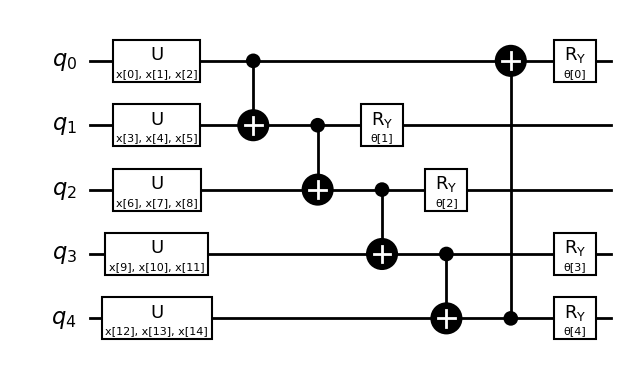

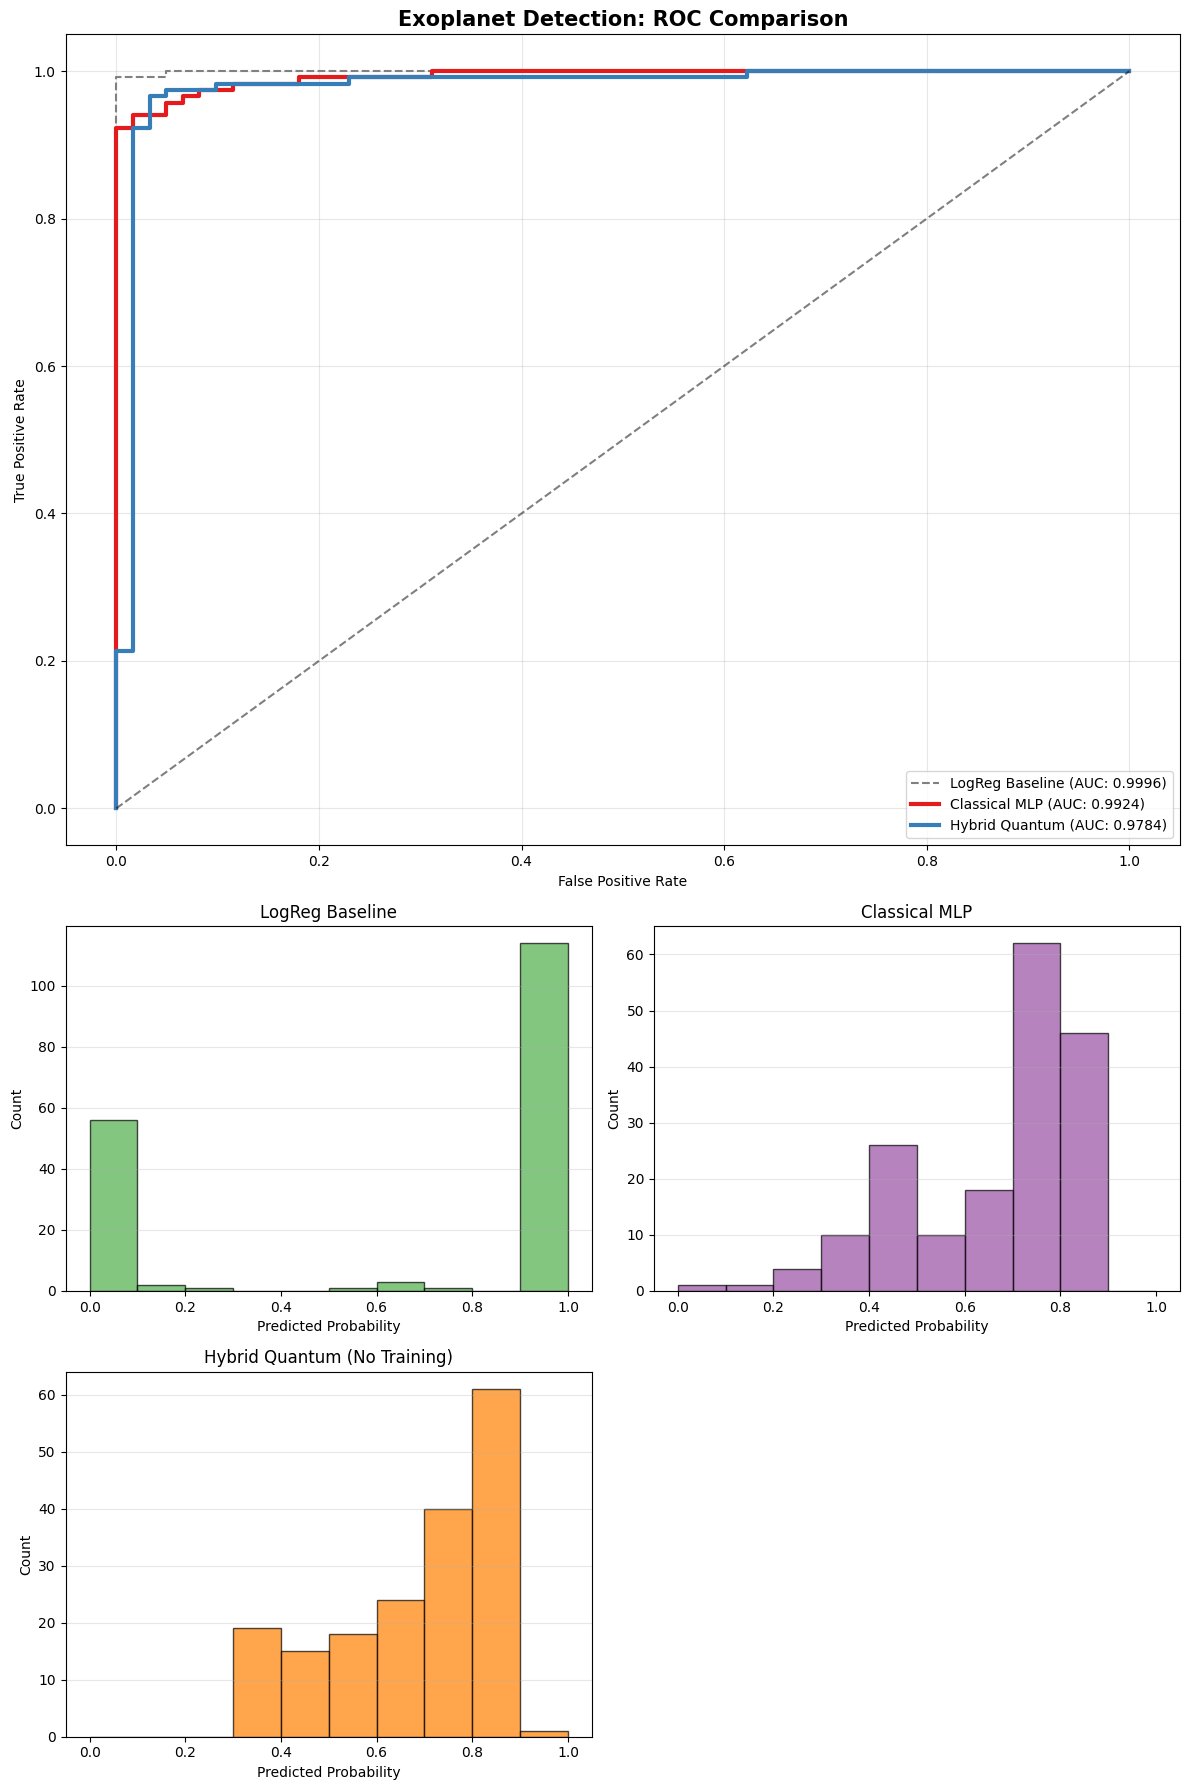


Final Comparison Table
           Logistic Regression  Classical NN    Hybrid
Accuracy              0.977528      0.893258  0.837079
F1                    0.983051      0.924901  0.888889
Recall                0.991453      1.000000  0.991453
Precision             0.974790      0.860294  0.805556
AUROC                 0.999580      0.992434  0.978422


In [21]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, roc_curve
)
from sklearn.decomposition import PCA

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.neural_networks import EstimatorQNN

path = "/content/Copy train_data - train_data.csv.csv"
features = [
    'koi_score', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_teq', 'koi_impact', 'koi_tce_plnt_num', 'koi_depth',
    'koi_steff', 'koi_prad', 'koi_fpflag_nt', 'koi_model_snr',
    'koi_slogg', 'koi_insol', 'koi_kepmag',
    'koi_period', 'koi_time0bk', 'koi_duration', 'ra', 'dec'
]

def load_data(path):
    df = pd.read_csv(path)
    available = [f for f in features if f in df.columns]
    if 'target' not in df.columns and 'koi_disposition' in df.columns:
        df['target'] = df['koi_disposition'].apply(lambda x: 1 if x == 'CONFIRMED' else 0)
    df = df[available + ['target']].dropna()
    return df[available].values, df['target'].values.astype(int), available

def preprocess_data(X_train, X_test, apply_pca=False, pca_n_components=None):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    num_features = X_train_scaled.shape[1]

    if apply_pca:
        if pca_n_components is None:
            pca_n_components = 0.95
        pca = PCA(n_components=pca_n_components)
        X_train_scaled = pca.fit_transform(X_train_scaled)
        X_test_scaled = pca.transform(X_test_scaled)
        num_features = pca.n_components_


    angle_scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
    X_train_angles = angle_scaler.fit_transform(X_train_scaled)
    X_test_angles = angle_scaler.transform(X_test_scaled)
    return X_train_angles, X_test_angles, num_features

#Quantum Circuit
def create_u_gate_circuit(num_input_features=15, num_qubits=5):
    f_per_q = 3
    actual_in = min(num_input_features, num_qubits * f_per_q)
    x, theta = ParameterVector('x', actual_in), ParameterVector('θ', num_qubits)
    qc = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        idx = i * f_per_q
        qc.u(x[idx % actual_in], x[(idx+1) % actual_in], x[(idx+2) % actual_in], i)
    for i in range(num_qubits - 1): qc.cx(i, i + 1)
    qc.cx(num_qubits - 1, 0)
    for i in range(num_qubits): qc.ry(theta[i], i)
    return qc, x, theta

#Classical Neural Network
class ClassicalNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

def train_and_evaluate_nn(X_train, X_test, y_train, y_test, epochs=30):
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    model     = ClassicalNet(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.002)
    criterion = nn.BCELoss()

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = model(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()
        preds = (probs > 0.5).astype(int)

    results = {
        'Accuracy' : accuracy_score(y_test, preds),
        'F1'       : f1_score(y_test, preds),
        'Recall'   : recall_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'AUROC'    : roc_auc_score(y_test, probs)
    }
    fpr, tpr, _ = roc_curve(y_test, probs)
    return results, fpr, tpr, probs, model

def run_logistic_regression(X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    preds = model.predict(X_test)

    results = {
        'Accuracy' : accuracy_score(y_test, preds),
        'F1'       : f1_score(y_test, preds),
        'Recall'   : recall_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'AUROC'    : roc_auc_score(y_test, probs)
    }
    fpr, tpr, _ = roc_curve(y_test, probs)
    return results, fpr, tpr, probs, model

# Visualizations
def plot_comprehensive_eval(nn_eval, hybrid_eval, lr_eval):
    res_n, fpr_n, tpr_n, probs_n = nn_eval
    res_h, fpr_h, tpr_h, probs_h = hybrid_eval
    res_l, fpr_l, tpr_l, probs_l = lr_eval

    fig = plt.figure(figsize=(12, 18))
    gs  = GridSpec(4, 2)
    colors = plt.get_cmap("Set1")

    ax_roc = fig.add_subplot(gs[:2, :2])
    ax_roc.plot(fpr_l, tpr_l, color='gray', linestyle='--',
                label=f'LogReg Baseline (AUC: {res_l["AUROC"]:.4f})')
    ax_roc.plot(fpr_n, tpr_n, color=colors(0), lw=3,
                label=f'Classical MLP (AUC: {res_n["AUROC"]:.4f})')
    ax_roc.plot(fpr_h, tpr_h, color=colors(1), lw=3,
                label=f'Hybrid Quantum (AUC: {res_h["AUROC"]:.4f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax_roc.set_title("Exoplanet Detection: ROC Comparison", fontsize=15, fontweight='bold')
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True, alpha=0.3)

    grid_positions = [(2, 0), (2, 1), (3, 0)]
    titles         = ["LogReg Baseline", "Classical MLP", "Hybrid Quantum"]
    all_probs      = [probs_l, probs_n, probs_h]

    for i in range(3):
        row, col = grid_positions[i]
        ax = fig.add_subplot(gs[row, col])
        ax.hist(all_probs[i], range=(0, 1), bins=10,
                color=colors(i+2), edgecolor='black', alpha=0.7)
        ax.set(title=titles[i], xlabel="Predicted Probability", ylabel="Count")
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Main
def main(data_fraction=1.0, circuit_builder=create_u_gate_circuit,
         apply_pca=False, pca_n_components=None, random_seed=42):

    X_full, y_full, feats_list = load_data(path)

    if data_fraction < 1.0:
        num_samples = int(len(y_full) * data_fraction)
        X_sampled, _, y_sampled, _ = train_test_split(
            X_full, y_full, train_size=num_samples,
            stratify=y_full, random_state=random_seed
        )
        X_full = X_sampled
        y_full = y_sampled

    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.2,
        random_state=random_seed, stratify=y_full
    )
    X_train_processed, X_test_processed, num_final_features = preprocess_data(
        X_train, X_test, apply_pca=apply_pca, pca_n_components=pca_n_components
    )


    print(f"Generating Circuit Diagram using {circuit_builder.__name__}...")
    qc, x_v, th_v = circuit_builder(num_final_features, 5)
    display(qc.draw(output='mpl', style='bw'))



    res_l, fpr_l, tpr_l, probs_l, lr_model = run_logistic_regression(
        X_train_processed, X_test_processed, y_train, y_test
    )


    res_n, fpr_n, tpr_n, probs_n, nn_model = train_and_evaluate_nn(
        X_train_processed, X_test_processed, y_train, y_test
    )

    # Quantum Feature Extraction
    n_qubits = 5
    observables = [
        SparsePauliOp.from_list([("I" * (n_qubits-1-i) + "Z" + "I" * i, 1)])
        for i in range(n_qubits)
    ]
    qnn = EstimatorQNN(
        circuit=qc,
        observables=observables,
        input_params=list(x_v),
        weight_params=list(th_v),
        estimator=StatevectorEstimator()
    )

    random_weights = np.random.rand(qnn.num_weights) * 2 * np.pi
    X_q_train = qnn.forward(X_train_processed, random_weights)
    X_q_test  = qnn.forward(X_test_processed,  random_weights)




    res_h, fpr_h, tpr_h, probs_h, hybrid_nn_model = train_and_evaluate_nn(
        X_q_train, X_q_test, y_train, y_test
    )

    # Plots
    plot_comprehensive_eval(
        (res_n, fpr_n, tpr_n, probs_n),
        (res_h, fpr_h, tpr_h, probs_h),
        (res_l, fpr_l, tpr_l, probs_l)
    )

    #Results table
    print("\n" + "="*40 + "\nFinal Comparison Table\n" + "="*40)
    print(pd.DataFrame(
        [res_l, res_n, res_h],
        index=["Logistic Regression", "Classical NN", "Hybrid"]
    ).T)

    return (lr_model, nn_model, X_test_processed, y_test,
            feats_list, res_h, fpr_h, tpr_h, probs_h)


if __name__ == "__main__":
    main(
        data_fraction=1.0,
        apply_pca=True,
        pca_n_components=15,
        random_seed=42
    )